# 🧠 01. 추론 방식 & 에이전트 루프 (Reasoning & Agent Loop)

본 실습 노트북은 **Naive ReAct Agent**의 기본 메커니즘과 한계를 살펴보고, **순수 Python 제어 루프**, **LangChain/LangGraph create_agent**, **Self-Recovery (에러 우회/장애 격리/서킷 브레이커)**, **Planner 패턴(Static vs Dynamic Replanning)**, 그리고 **멀티에이전트 오케스트레이션(Sub Agent)** 를 학습합니다.

---

### 💡 핵심 학습 내용

1. **ReAct (Reasoning + Acting) 루프**: Thought ➔ Action ➔ Observation 반복을 통한 자율적 문제 해결
2. **자가 복구 (Self-Recovery)**: 주 모델 장애 시 에러 우회(Fallback), 도구 예외 격리, 무한 루프 서킷 브레이커
3. **Planning & Blackboard Pattern**: 거시적 계획 분해와 동적 재계획(Replanning)을 통한 복잡한 다단계 미션 완수
4. **Subagent & Context Isolation**: 단일 에이전트의 컨텍스트 오염을 막기 위한 작업 위임 및 요약 합성

---

### 🎓 학습 목차 (Curriculum Flow)

| 파트 | 주제 | 핵심 내용 |
|:---:|:---|:---|
| **Step 0** | **환경 세팅** | 루트 경로 탐색, `.env` 로드, `nest_asyncio`, `init_chat_model` 초기화 |
| **Part 1** | **Naive ReAct 에이전트 이해 및 구축** | Pure Python `while` 루프 구현 vs LangChain `create_agent` 비교 |
| **Part 2** | **에이전트 하네스를 이용한 장애 수습 실습** | 에러 우회(Fallback), 장애 격리(Tool Error), 서킷 브레이커(Call Limit) 3대 안전망 실습 |
| **Part 3** | **3가지 Planner 패턴 정량적 비교 실습** | Naive vs Static Plan vs Dynamic Plan-and-Solve 비교 분석 |
| **Part 4** | **Multi-Agent & AgentTool (정보 불균형 5대 프로토콜)** | Supervisor-Worker 분리와 Blackboard Handover 검증 |

---

## 🛠️ Step 0. 환경 세팅

필요한 패키지를 로드하고 프로젝트 루트 경로 및 비동기 이벤트 루프(`nest_asyncio`)를 설정합니다.

In [ ]:
import os
import sys
import re
import json
import time
import asyncio
import nest_asyncio
from dotenv import load_dotenv

# 1. 주피터 노트북 비동기 루프 중복 방지
nest_asyncio.apply()

# 2. 프로젝트 루트 상향 동적 탐색 (어느 서브 폴더에 노트북이 있어도 100% 작동)
def find_project_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, "app")) and (
            os.path.exists(os.path.join(p, ".env")) or os.path.exists(os.path.join(p, "configs"))
        ):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.join(os.getcwd(), ".."))

project_root = find_project_root()
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 3. 환경변수 명시적 로드
dotenv_path = os.path.join(project_root, ".env")
load_dotenv(dotenv_path, override=True)

# LangSmith / LangChain Tracing 경고 차단
os.environ["LANGCHAIN_TRACING_V2"] = "false"

print(f"✅ Working Directory: {os.getcwd()}")
print(f"✅ Project Root: {project_root}")

from typing import List, Dict, Any, Optional
from pydantic import BaseModel, Field

# 4. LangChain 핵심 모듈 및 LLM 팩토리 임포트
from app.utils import init_chat_model, normalize_content
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langgraph.checkpoint.memory import MemorySaver


print("✅ Environment & Core Modules Initialized Successfully!")


--- 
## 📌 Part 1. Naive ReAct 에이전트 이해 및 구축

### 1. ReAct (Reasoning + Acting) 에이전트 워크플로우

ReAct 에이전트는 사용자의 질문을 해결하기 위해 **생각(Thought) ➔ 행동(Action) ➔ 관찰(Observation)**의 주기를 반복하며 자율적으로 의사를 결정하는 대표적인 에이전트 아키텍처입니다.



#### 💡 핵심 개념 요약
- **Thought (사고)**: 현재 상황에서 무엇을 해야 하는지, 어떤 도구(Tool)가 필요한지 LLM이 스스로 추론합니다.
- **Action (행동)**: 추론한 결과를 바탕으로 매개변수를 생성하여 도구(Tool)를 직접 실행(호출)합니다.
- **Observation (관찰)**: 도구의 실행 결과값을 확인하여 컨텍스트에 갱신하고 다음 행동을 결정합니다.

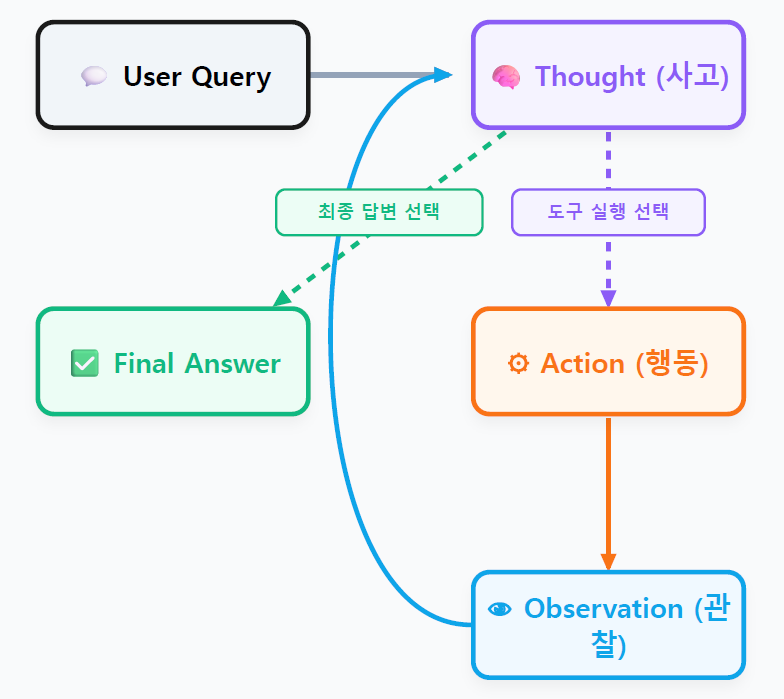

### 2. Pure Python으로 구현하는 ReAct Loop
Claude Code의 `query.ts`나 Hermes의 `conversation_loop.py`의 핵심은 외부 프레임워크 없이 **Python의 기본 제어 루프(`while True`)**와 정규식 파싱을 활용해 에이전트를 조율하는 것입니다.

아래 실습 코드는 LLM 호출 결과를 파싱하여 도구 실행과 결과 합성을 수동으로 반복하는 순수 파이썬 ReAct 루프 구조입니다.

In [ ]:
# 1. 실습용 간단한 모의 도구 선언 (정규식 필터링 안정화)
def mock_calculator(expression: str) -> str:
    try:
        # 사칙연산에 불필요한 모든 문자(알파벳 s 포함)를 원천 차단
        clean_expr = re.sub(r'[^0-9+\-*/().]', '', expression)
        return str(eval(clean_expr))
    except Exception as e:
        return f"Error evaluating: {str(e)}"

tools_map = {"calculator": mock_calculator}

# 2. Pure Python ReAct 실행 루프 정의
def run_pure_react_loop(user_query: str, model_name: str = "gemini-3.5-flash"):
    # init_chat_model은 환경변수 상태에 따라 google_vertexai 또는 google_genai로 자동 분기
    llm = init_chat_model(model=model_name, temperature=0.0)
    
    system_prompt = (
        "You are a ReAct Agent. Solve the task step-by-step.\n"
        "You have access to the tool: calculator(expression: str).\n"
        "Your output must follow this format EXACTLY:\n"
        "Thought: [your reasoning here]\n"
        "Action: tool_name(arguments)\n"
        "Observation: [will be provided by the system]\n"
        "... (repeat if needed)\n"
        "Final Answer: [final response to user]\n"
    )
    
    trajectory = [SystemMessage(content=system_prompt), HumanMessage(content=user_query)]
    
    print(f"🚀 [Query]: {user_query}\n")
    
    step = 0
    while step < 5:
        step += 1
        print(f"--- [Turn {step}] ---")
        
        # LLM에게 현재까지의 흐름 전달
        resp = llm.invoke(trajectory)
        raw_content = resp.content
        
        # AAWS 공통 message_utils의 normalize_content를 사용하여 일관성 있게 텍스트 정규화
        llm_text = normalize_content(raw_content)
        print(llm_text)
        
        trajectory.append(AIMessage(content=raw_content))
        
        # Final Answer 체크
        if "Final Answer:" in llm_text:
            print("\n✅ ReAct Loop Completed!")
            break
            
        # Action 파싱
        action_match = re.search(r"Action:\s*(\w+)\((.*?)\)", llm_text)
        if action_match:
            tool_name = action_match.group(1)
            tool_arg = action_match.group(2).strip('"\' ')
            
            # parameter=value 형태로 넘어왔을 때 value만 발라내기
            if "=" in tool_arg:
                tool_arg = tool_arg.split("=", 1)[1].strip('"\' ')
            
            if tool_name in tools_map:
                print(f"⚙️ [System Executing]: {tool_name}({tool_arg})")
                obs_result = tools_map[tool_name](tool_arg)
                print(f"👁️ [Observation]: {obs_result}\n")
                
                # 관찰 내용을 히스토리에 가재
                trajectory.append(HumanMessage(content=f"Observation: {obs_result}"))
            else:
                trajectory.append(HumanMessage(content=f"Observation: Error, Tool {tool_name} not found."))
        else:
            print("⚠️ Failed to parse Action format. Exiting loop.")
            break

# 실행 테스트
run_pure_react_loop("법인카드 지출액인 $1200에서 10%의 세금을 제외한 금액을 계산해 줘.")

### 3. LangChain/LangGraph 에이전트 프레임워크 도입

직접 `while True` 제어 루프를 구성하는 방식은 에이전트의 작동 방식을 명확히 보여주지만 개발 복잡도가 높다는 단점을 가집니다:

1. **예외 처리 및 포맷 오류**: LLM이 지정된 `Action:` 규칙을 조금이라도 어기면 파서가 붕괴합니다.
2. **메모리 체크포인터 관리**: 영속적인 대화 맥락을 파일/DB에 안전하게 동기화하려면 추가 코드가 필요합니다.
3. **도구 파이프라인의 비표준화**: 매개변수 유효성 검사(Type Validation)를 매번 직접 작성해야 합니다.

**LangChain / LangGraph 프레임워크**를 도입하면 이 제어 로직과 메모리 체크포인터 관리를 고도로 추상화된 단 한 줄의 모듈식 코드로 대체할 수 있습니다.

In [ ]:
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# 1. 도구 선언
@tool
def calculate_budget(total_amount: float, tax_rate: float = 0.1) -> str:
    """Calculates net amount after applying tax rate."""
    net = total_amount * (1.0 - tax_rate)
    return f"Total: {total_amount}, Net Budget after Tax ({tax_rate*100}%): {net}"

@tool
def search_policy(query: str) -> str:
    """Searches corporate spending policy documents."""
    query_lower = query.lower()
    if "weekend" in query_lower or "주말" in query_lower:
        return "[Policy Rule] Weekend spending requires prior approval from department lead."
    elif "limit" in query_lower or "한도" in query_lower:
        return "[Policy Rule] Single expense limit per transaction is $500."
    return "[Policy Rule] All expenses must include legitimate tax receipt."

tools = [calculate_budget, search_policy]

# 2. init_chat_model 중앙 팩토리로 LLM 로드 (하이브리드 환경 지원)
model_name = os.getenv("DEFAULT_MODEL_NAME") or "gemini-3.5-flash"
llm = init_chat_model(model=model_name, temperature=0.0)

# 3. 단기 대화 이력을 영속 보존할 내장 메모리 세이버 가동
checkpointer = InMemorySaver()

# 4. LangChain 표준 create_agent API로 에이전트 빌드
system_prompt_str = "You are a helpful assistant. Solve user requests step-by-step using available tools."
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt_str,
    checkpointer=checkpointer
)

# 5. 에이전트 단기 메모리 세션 생성 및 가동
config = {"configurable": {"thread_id": "naive_react_session_777"}}
query = "내 법인카드 지출 금액 $600에 대해 10% 세금을 제하고 남은 예산을 계산해 주고, 주말 사용 관련 정책을 확인해 줘."

print(f"🔄 [System] 표준 LangChain ReAct 에이전트 실행 중... (세션: naive_react_session_777)\n")
inputs = {"messages": [HumanMessage(content=query)]}
result = agent.invoke(inputs, config=config)

# 6. 최종 AI 응답 메시지 추출 및 turns 정보 출력
messages = result.get("messages", [])
final_text = ""
if messages:
    final_text = normalize_content(messages[-1].content)

print("=== LangChain ReAct Agent Output ===")
print(final_text)
print(f"Total Execution Turns: {len(messages)}")

In [ ]:
# 7. 메시지 리스트 출력
for m in messages:
    m.pretty_print()

### 🛠️ 하네스 OS의 핵심 9대 구성 요소
에이전트 하네스(Harness)는 단순한 LLM API 호출 래퍼가 아닙니다. 아래와 같이 9대 중재 장치를 통해 비결정적인 인공지능을 엔터프라이즈 환경에 맞게 제어하는 에이전트 전용 운영체제(OS)의 역할을 수행합니다.
- **메모리 / 스킬 / 프로토콜**: 4계층 장기 기억 보존, ACI 스킬 셋 정의, 정보 불균형 해소
- **샌드박스 / LLM 엔진 / 추론 패턴**: 격리 환경 도구 실행, 하이브리드 모델 스위칭, 3대 플래너 통제
- **관측성 / 승인 게이트 / 가드레일**: 실행 궤적 실시간 모니터링, Allow/Ask/Deny 승인, 프롬프트 주입 차단
---

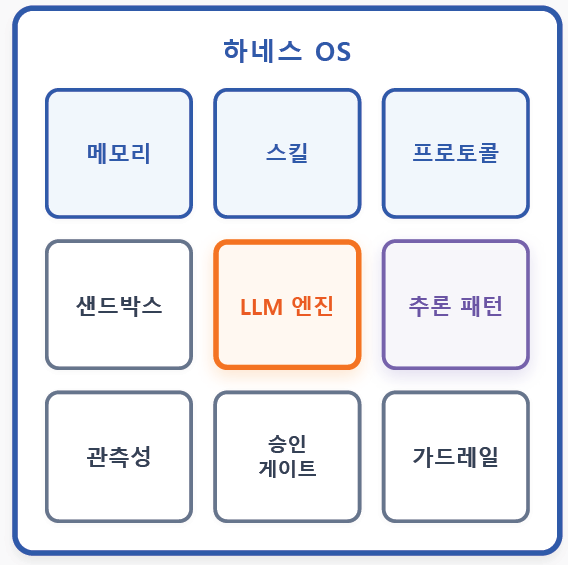 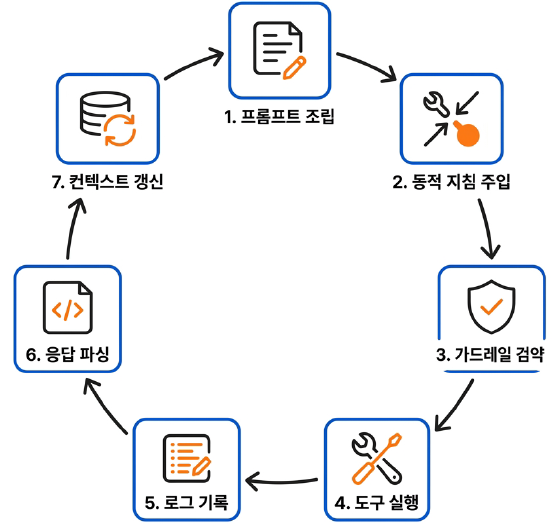

### Case Study : Claude Code `query Loop` 5단계 자율 순환 구조
Claude Code 가 매 턴 사용자 명령을 도구를 사용해 해결해 나가는 핵심 5단계 자율 순환 프로세스는 다음과 같습니다.
1. **1단계 - Compaction (컨텍스트 압축)**:
   - 과도한 토큰 소모와 프롬프트 한계 도달을 막기 위해 **Snip(오래된 도구 로그 잘라내기)**, **Micro/Auto-Compaction(대량 도구 출력 병합)** 및 **Collapse(비활성 텍스트 접기)**를 수행합니다.
2. **2단계 - Model Call (모델 스트리밍 호출)**:
   - 5계층 정적/동적 프롬프트 조립 : System prompt + Tool spec + contexts(메모리, Skills.md, AGENT.md, ...)
   - 대화 이력 결합
   - 스트리밍 방식의 모델 호출
3. **3단계 - Error Withholding & Recovery (반응형 오류 복구)**:
   - Model call과 Tool call 과정에서 발생하는 다양한 오류 복구
       - 예시 ) API 통신 시 413 (Payload Too Large) 콘텍스트 오버플로우가 감지되면 하네스가 예외를 즉시 가로채고 **반응형 압축(Reactive Compaction)** 을 자동 구동하여 루프를 중단 없이 복구
5. **4-1 단계 - Tool Execution & Governance (도구 실행 및 거버넌스)**:
   - 도구 호출 명령 발생 시, 사용자가 사전에 정의한 **Allow/Ask/Deny 승인 게이트**를 통과시킵니다.
   - 안전 도구는 **최대 10개까지 병렬 비동기 실행**하고, 파일 쓰기 및 Bash 명령어 같은 위험 도구는 순차 실행합니다.
   - 도구 호출 스키마 검사 후 **1단계로 즉시 재진입**
6. **4-1 단계 - Final Answer & Post-processing**:
   - 최종 답변 생성 및 평가
   - 문제 없을 경우 루프 종료

```
async def run_claude_query_loop(user_query: str):
    # 초기 컨텍스트 설정 (System Prompt + User Input)
    messages = [
        SystemMessage(content=STATIC_5LAYER_PROMPT), 
        과거 대화 메시지들, .... HumanMessage(content=user_query)
    ]
    
    while True:
        #----------------------------------------------------------------------
        # [Step 1] Message Preprocessing (컨텍스트 정화 및 압축)
        #----------------------------------------------------------------------
        # - Snip: 이전 턴의 오래된 도구 실행 결과 로그를 잘라내어 캐시 세이브
        # - Compact: 도구 출력값의 메타데이터만 남기고 경량화
        compacted_messages = context_preprocessor.compact(messages)
        
        try:
            #----------------------------------------------------------------------
            # [Step 2] API Streaming Call (스트리밍 모델 호출)
            #----------------------------------------------------------------------
            stream = await llm.astream_call(
                messages=compacted_messages,
                tools=AVAILABLE_TOOLS_SCHEMA
            )
            llm_response = await stream.read_to_end()
            
        except APIError as error:
            #----------------------------------------------------------------------
            # [Step 3] Error Withholding & Recovery (반응형 자가 복구)
            #----------------------------------------------------------------------
            # 컨텍스트 오버플로우(413 Error) 발생 시 하네스가 가로채서 복구 시도
            if error.status_code == 413:
                # 즉각적인 하드 압축(Reactive Compaction) 후 루프 재진입
                messages = context_preprocessor.reactive_compact_harder(messages)
                print("🔄 [Harness Recovery] 413 Context Overflow Detected. Compaction applied. Retrying...")
                continue
            else:
                raise error
        
        #----------------------------------------------------------------------
        # [Step 4] Tool Execution & Governance (도구 실행 통제 및 승인 게이트)
        #----------------------------------------------------------------------
        if llm_response.tool_calls:
            tool_results = []
            
            for call in llm_response.tool_calls:
                # 거버넌스 승인 게이트 (Allow / Ask / Deny) 작동
                permission = await approval_gate.verify(call.name, call.args)
                
                if permission == "DENIED":
                    tool_results.append(ToolMessage(content="Error: Execution denied by user.", tool_call_id=call.id))
                    continue
                
                # 안전한 읽기/조회 도구는 비동기 병렬(Parallel Max 10) 실행
                # 위험한 쓰기/명령어 도구는 직렬 순차 실행 및 샌드박스 격리
                result = await sandbox.execute(call.name, call.args)
                tool_results.append(ToolMessage(content=result, tool_call_id=call.id))
            
            # 실행 결과를 궤적(Trajectory)에 누적
            messages.append(llm_response)
            messages.extend(tool_results)
            
            #----------------------------------------------------------------------
            # [Step 5] Post-processing & tool_use 검사 (루프 지속)
            #----------------------------------------------------------------------
            continue # 다음 턴(Turn) 실행을 위해 루프 재진입
            
        else:
            # 더 이상 실행할 도구 호출이 없는 경우 루프 탈출
            # stopHook 등의 후처리 필터를 통과시킨 후 최종 답변을 반환
            final_answer = await stop_hook.filter(llm_response.content)
            return final_answer

```

### 🔌 LangChain Middleware 기반의 비침습적 하네스 설계

에이전트가 호출되는 라이프사이클의 특정 지점(Hooks)에 미들웨어를 배치하여, 에이전트 본체 코드를 한 줄도 수정하지 않고 보안 가드레일, 컨텍스트 압축, 권한 제어 등의 하네스 OS를 통합할 수 있습니다.

#### 🛡️ 에이전트 제어를 위한 6대 핵심 미들웨어 훅 (Hooks)

1. **`before_agent` (에이전트 진입 직전)**:
   - 사용자의 최초 입력을 가로채 가드레일 검사(탈옥 및 프롬프트 인젝션 차단)를 수행합니다.
   - 단기 메모리 및 장기 메모리(Recalled Memory)를 사전 병합합니다.

2. **`before_model` (LLM 호출 직전)**:
   - LLM에 메시지를 쏘기 바로 직전에 가동됩니다.
   - 컨텍스트 오버플로우를 감지하고 **Auto-Compaction(궤적 압축)** 또는 **Context Drain**을 수행해 보낼 메시지의 토큰을 최종 정화합니다.

3. **`wrap_model_call` (LLM 통신 래핑)**:
   - 실제 LLM API 호출을 물리적으로 감싸는 계층입니다.
   - API 통신 중 발생하는 413 에러를 모니터링하여 자가 복구 루틴을 트리거하거나 호출 지연 시간(Latency) 및 비용(Token Cost)을 기록합니다.

4. **`after_model` (LLM 응답 직후)**:
   - LLM이 내놓은 생각을 파싱하여 `Final Answer`인지 혹은 `Tool Call (도구 실행)` 지시인지를 판단하여 분기합니다.

5. **`wrap_tool_call` (도구 실행 래핑)**:
   - 도구가 실제로 작동하기 직전에 가로챕니다.
   - **승인 게이트(Allow / Ask / Deny)**를 가동하여 사용자 동의를 구하거나, 도구 에러 발생 시 예외 피드백을 가재하여 자가 치유(Self-correction)를 유도합니다.

6. **`after_agent` (에이전트 종료 직후)**:
   - 에이전트가 동작을 멈추고 최종 답을 반환하기 직전 필터를 거칩니다.
   - **stopHook**을 가동해 부적절한 답변을 차단(민감 정보 마스킹)하고, 이번 세션에서 총 소모한 자원의 메타데이터를 로깅합니다.


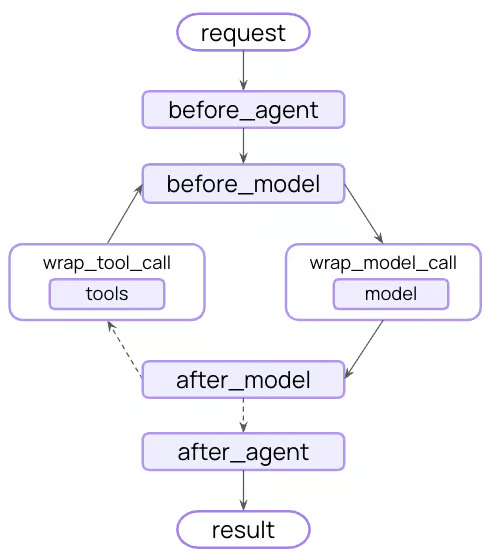

---
## 📌 Part 2. 에이전트 하네스를 이용한 Agent Loop 내 Self-recovery

토이 프로젝트 수준의 에이전트는 해피 패스(Happy Path)에서만 작동합니다. 그러나 프로덕션 에이전트는 불안정한 시스템 장애에 직면합니다.

상용 에이전트들은 다음과 같은 **자가 복구(Self-Recovery) 및 자가 교정(Self-Correction)** 메커니즘이 내장되어 있습니다.

#### 🔑 핵심 개념: Self-Recovery vs Self-Correction

| 구분 | 🛡️ Self-Recovery (자가 복구) | 🧠 Self-Correction (자가 교정) |
| :--- | :--- | :--- |
| **복구 주체** | **하네스(미들웨어/런타임)** — LLM 개입 없이 직접 처리 | **LLM(에이전트)** — 하네스는 피드백만 주입 |
| **문제 성격** | 시스템/운영 장애 (API 429, 503, 통신 순단, 무한 루프) | 인지/의미론적 오류 (문법 에러, JSON 불일치, 환각) |
| **작동 메커니즘** | Retry, Failover, Loop Breaker, Checkpoint Rollback | Reflection, Feedback Loop, StopHook 피드백 주입 |
| **LLM 인지 여부** | ❌ 에이전트는 뒷단의 복구를 **모름** (투명) | ✅ 에이전트가 오류를 **인지하고 재추론** |

> 💡 오늘은 **에이전트 루프의 생존성을 보장하는 Self-Recovery 2대 미들웨어**를 실습합니다.
> Self-Correction(StopHooks 기반 출력 품질 교정)은 Day 2 평가 모듈에서 심화합니다.

#### 🚨 Claude Code에서 정의한 대표적인 장애 극복 사례
1. **Transient API & Rate Limit Error (429/503)** → 지수 백오프 재시도 + 백업 모델 전환 (Failover)
2. **Infinite Loop / Cost Runaway** → 모델 호출 횟수 제한 (`ModelCallLimitMiddleware`)으로 강제 차단
3. **Context Window Exceeded (413)** → 반응형 압축 (→ 4번 노트북에서 실습)
4. **Output Quality Defect** → StopHook 피드백 주입 (→ Day 2에서 실습)

### 🔌 에이전트 하네스 미들웨어 패키지 설계 명세

에이전트 본체 코드를 한 줄도 수정하지 않고(비침습적으로) 장애를 극복하기 위해, `error_control` 패키지를 구축했습니다.

* 📄 **미들웨어 소스코드 경로**: `app/middleware/error_control/`

| 미들웨어 | 분류 | 가동 훅 | 복구 로직 | 효과 |
| :--- | :---: | :--- | :--- | :--- |
| **`ModelFallbackMiddleware`** | **Custom** | `@wrap_model_call` | Phase 1: Retryable 에러 필터링 → 지수 백오프 재시도. Phase 2: 주 모델 실패 → 백업 모델 투명 전환. Phase 3: 백업도 실패 → 안전 메시지. | **LLM API 무중단 복구** |
| **`ToolErrorHandlerMiddleware`** | **Custom** | `@wrap_tool_call` | 도구 실행 예외를 가로채 에러 정보를 ToolMessage(Observation)로 변환. LLM이 에러를 관찰하여 자율적 재시도/우회 결정. | **도구 크래시 방지** |
| **`ModelCallLimitMiddleware`** | **Built-in** | `@before_model` / `@after_model` | 단일 invoke당 모델 호출 횟수가 `run_limit`에 도달하면 강제 종료. | **무한 루프 & 과금 폭탄 방지** |

### 📁 `error_control` 패키지 구조

```
app/middleware/error_control/
├── __init__.py
└── self_recovery/               # [Day 1 실습] 시스템/인프라 장애 복구
    ├── model_fallback.py        # ModelFallbackMiddleware (Retry+Fallback 통합)
    ├── tool_error_handler.py    # ToolErrorHandlerMiddleware (도구 에러 → Observation)
    └── abort_handlers.py        # AbortStreaming/ToolsMiddleware

```

In [ ]:
import os
import time
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import MemorySaver

from app.utils import init_chat_model, normalize_content
from app.middleware.error_control.self_recovery import ModelFallbackMiddleware, ToolErrorHandlerMiddleware

# =============================================================================
# 1. 장애 시뮬레이션용 도구(Tools) 정의
# =============================================================================

@tool
def simple_calculator(expression: str) -> str:
    """Evaluates simple arithmetic expressions (e.g. '2 + 3')."""
    try:
        result = eval(expression)
        return f"Result: {result}"
    except Exception as e:
        return f"Calculation error: {e}"

@tool
def monitor_process_updates(task_name: str) -> str:
    """Checks progress of task. Returns PENDING forever to trigger infinite loop."""
    return f"Task '{task_name}' Status: IN_PROGRESS (PENDING). Re-check in a few seconds."

# 통신 장애 카운트용 전역 변수
_network_call_count = 0

@tool
def flaky_network_api(payload: str) -> str:
    """Sends database commit. Simulates transient 503 network dropouts."""
    global _network_call_count
    _network_call_count += 1
    if _network_call_count < 3:
        time.sleep(3)
        raise ConnectionResetError("503 Service Unavailable: Connection reset by peer.")
    return "SUCCESS: Payload successfully registered in remote database."

print("✅ 장애 시뮬레이션 도구 3종 정의 완료")
print("   - simple_calculator: 정상 도구 (산술 계산)")
print("   - monitor_process_updates: 영원히 PENDING 반환 (무한 루프 유발)")
print("   - flaky_network_api: 처음 2회 호출 시 ConnectionResetError 발생")

### 🔥 실험 1: LLM API 장애 → `ModelFallbackMiddleware` 투명 복구

주 모델을 **존재하지 않는 모델명**으로 설정하여 LLM API 호출을 고의로 실패시킵니다.  
`ModelFallbackMiddleware`가 `@wrap_model_call` 훅에서 에러를 가로채고, **백업 모델로 투명하게 전환**합니다.

> 💡 에이전트(LLM)는 **뒤에서 모델이 교체된 사실을 모릅니다**. 하네스가 투명하게 처리했기 때문입니다.  
> 이것이 Self-Recovery의 핵심 — **LLM 개입 없이 하네스가 직접 복구**합니다.

In [ ]:
# [실험 1] LLM API 장애 → ModelFallbackMiddleware 투명 복구 테스트

# ❌ 주 모델: 존재하지 않는 모델 → API 호출 시 반드시 실패
broken_llm = init_chat_model(model="nonexistent-model-xxx", model_provider="openai", temperature=0.0)
backup_model = os.getenv("DEFAULT_MODEL_NAME") or "gemini-2.5-flash"

agent_exp1 = create_agent(
    model=broken_llm,  # ← 이 모델은 호출하면 반드시 에러
    tools=[simple_calculator],
    system_prompt="You are a helpful assistant. Use tools when needed.",
    checkpointer=MemorySaver(),
    middleware=[
        ModelFallbackMiddleware(
            max_retries=1,                    # 재시도 1회만 (데모 속도)
            fallback_model_name=backup_model,  # ← 이 백업이 살려줌
        ),
    ]
)

config_1 = {"configurable": {"thread_id": "model_fallback_session"}}
print(f"🔥 [실험 1] 깨진 주 모델 'nonexistent-model-xxx' → 백업 모델 '{backup_model}' 자동 전환 테스트...")
print(f"{'='*60}")

query = "2 + 3을 계산해 줘."
result = agent_exp1.invoke({"messages": [HumanMessage(content=query)]}, config=config_1)

print(f"\n{'='*60}")
print(f"✅ 최종 결과: {normalize_content(result['messages'][-1].content)[:300]}")
print(f"📊 총 메시지 수: {len(result['messages'])}")

### 🔥 실험 2: 도구 실행 에러 → `ToolErrorHandlerMiddleware` 안전 복구

`flaky_network_api` 도구는 처음 2회 호출 시 `ConnectionResetError`를 raise합니다.  
`ToolErrorHandlerMiddleware`가 `@wrap_tool_call` 훅에서 예외를 가로채고, **에러 정보를 ToolMessage(Observation)로 변환**합니다.

에이전트(LLM)는 에러 메시지를 읽고 **자율적으로 재호출을 결정**합니다.

> 💡 이 미들웨어가 없으면 도구의 `raise`가 에이전트 전체를 크래시시킵니다.  
> 미들웨어가 에러를 "관찰값(Observation)"으로 변환해야 에이전트가 대응할 수 있습니다.

In [ ]:
# [실험 2] 도구 실행 에러 → ToolErrorHandlerMiddleware 안전 복구 테스트

_network_call_count = 0  # 카운트 초기화
model_name = os.getenv("DEFAULT_MODEL_NAME") or "gemini-2.5-flash"
llm = init_chat_model(model=model_name, temperature=0.0)

agent_exp2 = create_agent(
    model=llm,
    tools=[flaky_network_api],
    system_prompt="You are a senior DevOps engineer. Execute tasks using available tools. If a tool fails, try again.",
    checkpointer=MemorySaver(),
    middleware=[
        ToolErrorHandlerMiddleware(),  # 도구 에러 → 안전한 ToolMessage로 변환
        ModelCallLimitMiddleware(run_limit=5, exit_behavior="end"),  # 안전장치
    ]
)

config_2 = {"configurable": {"thread_id": "tool_error_session"}}
print("🔥 [실험 2] 도구 503 에러 발생 → ToolErrorHandler가 에러를 Observation으로 변환 → 에이전트 자율 재시도...")
print(f"{'='*60}")

query = "flaky_network_api 도구로 'critical_backup_data' 페이로드를 데이터베이스에 등록해 줘."
result = agent_exp2.invoke({"messages": [HumanMessage(content=query)]}, config=config_2)

print(f"\n{'='*60}")
print(f"✅ 최종 결과: {normalize_content(result['messages'][-1].content)[:300]}")
print(f"📊 총 메시지 수: {len(result['messages'])}")

In [ ]:
for m in result['messages']:
    m.pretty_print()

### 🔥 실험 3: 무한 루프(PENDING 폭주) → `ModelCallLimitMiddleware` 강제 차단

`monitor_process_updates` 도구는 **항상 `IN_PROGRESS (PENDING)` 상태**를 반환합니다.  
에이전트는 "완료될 때까지 계속 확인해 달라"는 지시를 받으면 영원히 도구를 호출하려 합니다.

`ModelCallLimitMiddleware(run_limit=3)`이 **3번째 모델 호출 시점에 루프를 강제 차단**합니다.

> 💡 이 미들웨어가 없으면 에이전트는 무한히 도구를 호출하여 **과금 폭탄(Cost Runaway)**이 발생합니다.

In [ ]:
# [실험 3] 무한 루프 강제 차단 테스트

model_name = os.getenv("DEFAULT_MODEL_NAME") or "gemini-2.5-flash"
llm = init_chat_model(model=model_name, temperature=0.0)

agent_exp3 = create_agent(
    model=llm,
    tools=[monitor_process_updates],
    system_prompt="You are a process monitor. Check task status using available tools.",
    checkpointer=MemorySaver(),
    middleware=[
        ModelCallLimitMiddleware(run_limit=3, exit_behavior="end"),  # 3회 초과 시 강제 종료
    ]
)

config_3 = {"configurable": {"thread_id": "infinite_loop_session"}}
print("🔥 [실험 3] PENDING 상태 지속 → 무한 루프 강제 종료 테스트...")
print(f"{'='*60}")

query = "monitor_process_updates로 'ReplicationTask'의 상태를 확인하고, COMPLETED가 될 때까지 계속 모니터링해 줘."
result = agent_exp3.invoke({"messages": [HumanMessage(content=query)]}, config=config_3)

print(f"\n{'='*60}")
print(f"💡 [Harness Result] 무한 루프 탈출 성공!")
print(f"📊 총 메시지 수: {len(result['messages'])}")
print(f"✅ 최종 메시지: {normalize_content(result['messages'][-1].content)[:300]}")

---

## 📌 Part 3. Planning & Task Board 도구 엔진 (Blackboard Pattern)

`app/tools/plan.py`는 Supervisor 전용의 **구조화된 5대 Planning 도구**로, 디스크 칠판(`plan_state.json`, `task_state.json`)을 조작합니다:

| 도구 명칭 | 기능 | 상태 파일 |
|:---|:---|:---|
| `enter_plan` | 거시적 실행 계획 등록 (Planning 모드 진입) | `plan_state.json` |
| `exit_plan` | Planning 모드 종료 및 상태 완료 처리 | `plan_state.json` |
| `task_create` | Task Board에 세부 하위 과제 등록 (ID 자동 발급) | `task_state.json` |
| `task_list` | Task Board의 전체 작업 목록 및 상태 조회 | `task_state.json` |
| `task_update` | 특정 과제 상태 갱신 (PENDING → IN_PROGRESS → COMPLETED / BLOCKED) | `task_state.json` |

문자열 치환(`file_edit`) 방식이 아닌, **JSON 기반 구조화 칠판**으로 LLM의 기억 오류로 인한 텍스트 매칭 실패를 원천 차단합니다.

In [ ]:
import os
import json

# 1. app/tools/plan.py 5대 Planning 도구 및 task_board 객체 임포트
from app.tools.plan import (
    enter_plan,
    exit_plan,
    task_create,
    task_list,
    task_update,
    task_board,
)

# 2. app/tools/common.py 공용 파일 도구 임포트
from app.tools.common import (
    file_read,
    file_writer,
    file_edit,
    grep_search,
)

# 3. app/middleware 시각화 미들웨어 임포트
from app.middleware import HierarchicalVisualizerMiddleware

# 4. 이전 Task Board 잔여 파일 및 메모리 완전 초기화
for f in ["task_state.json", "plan_state.json"]:
    if os.path.exists(f):
        os.remove(f)

task_board.tasks.clear()

print("✅ Production Tools & Middleware Imported Successfully!")
print("   📋 Planning Tools: enter_plan, exit_plan, task_create, task_list, task_update")
print("   🧹 Task Board & Plan State Cleaned!")

In [ ]:
# [데모] Planning 도구 단독 테스트
print("\n" + "=" * 50)
print("📋 [Demo] Planning 도구 단독 호출 테스트")
print("=" * 50)

print("\n1️⃣ enter_plan:")
print(enter_plan.invoke({"plan_name": "카페 상권 분석 데모", "steps": ["Step 1: 데이터 확인", "Step 2: 분석 실행"]}))

print("\n2️⃣ task_create:")
print(task_create.invoke({"task_description": "Step 1: 데이터 확인"}))

print("\n2️⃣ task_create:")
print(task_create.invoke({"task_description": "Step 2: 분석 실행"}))

print("\n3️⃣ task_list:")
print(task_list.invoke({}))

print("\n4️⃣ task_update:")
print(task_update.invoke({"task_id": 1, "status": "COMPLETED"}))

print("\n4️⃣ task_update:")
print(task_update.invoke({"task_id": 2, "status": "COMPLETED"}))

print("\n3️⃣ task_list:")
print(task_list.invoke({}))

print("\n5️⃣ exit_plan:")
print(exit_plan.invoke({"plan_name": "카페 상권 분석 데모", "status": "COMPLETED"}))

task_board.tasks.clear()

# 데모 상태 정리
for f in ["task_state.json", "plan_state.json"]:
    if os.path.exists(f):
        os.remove(f)
print("\n✅ Planning 도구 데모 완료 및 상태 초기화!")

---

## 📌 Part 4. 멀티에이전트 정보 불균형(Information Asymmetry)과 5대 협업 프로토콜

### 4.1 멀티에이전트 시스템의 최대 난제: 정보 불균형

멀티 에이전트를 실무 프로젝트에 투입할 때 발생하는 성능 저하와 실패의 90% 이상은 **"부모와 자식 간 정보의 비효율적 전달 및 컨텍스트 뒤섞임"** 에서 기인합니다:

특히 작업 위임 방식에서 subagent는 handoff 방식에 비해 토큰 효율성은 좋으나 Supervisor(상위) <=> Worker(하위) 사이의 정보 격리 문제가 있습니다.

- Supervisor는 작업의 전역 맥락만을 알고 있습니다.
- Worker는 작업의 세부 맥락만을 알고 있습니다.


**추론의 단절 (Reasoning Mismatch)**: Worker가 에러를 만났을 때, Supervisor와 실시간 대화 없이 자율 치유가 어렵습니다.

### 4.2 정보 불균형 극복을 위한 5대 협업 프로토콜

| 프로토콜 명칭 | 구체적 매커니즘 (Mechanism) | 정보 불균형 극복 효과 (Effect) |
| :--- | :--- | :--- |
| **`Dynamic Context Pruning`**<br>(동적 가지치기) | 부모가 자식을 호출할 때 오직 타겟 소스 파일과 구체 지시문만 전달. | 자식의 **입력 토큰 절감** 및 집중도 극대화. |
| **`Backtracking`**<br>(백트래킹 예외 복구) | 자식이 치명적 에러 시 실패 원인을 규격에 맞춰 부모에게 반환. | 부모가 **이전 단계로 되돌아가 2차 계획 수립**. |
| **`Blackboard Pattern`**<br>(공유 칠판 동기화) | 공유 파일(e.g task_state.json)을 공유 칠판으로 삼아 작업 현황을 지속 기록 및 인계. | 다중 자식 간 **상태 동기화 불일치 차단**. |
| **`Self-directed Gathering`**<br>(자율 정보 수집) | 자식이 정보 부족 시 탐색 툴(`Grep`, `FileRead`)로 직접 맥락 수집. | 불필요한 **핑퐁 통신 제거**. |
| **`Prompt Layering`**<br>(계층형 프롬프팅) | 자식에게 "대화형이 아닌 작업 모드, 침묵 실행, 구조화된 결과"라는 Worker 전용 프롬프트 강제. | **자식 에이전트의 툴 실행 성공률 급증**. |

---

### 📌 invoke_sub_agent 프로덕션 설계 규약

`app/tools/supervisor_tools.py`에 구현된 프로덕션 `invoke_sub_agent`의 핵심 설계:

#### 3-Layer 메시지 빌더 (Prompt Layering & Protocol Header 주입)

> 💡 **Prompt Layering 핵심 원칙**:
> - **Worker Base System Prompt**: 순수한 '전문가 정체성(Base Persona)' 및 도구 활용 지침만 정의합니다.
> - **Protocol Header (`_FULL_PROTOCOL_HEADER`)**: Sub-agent 제어 규약(`No chit-chat`, `[BLOCKER]`, `[TASK REPORT]`)과 타겟 파일 목록은 **호출 메시지(HumanMessage)의 헤더로 동적 오버레이(주입)**합니다.
> - 이를 통해 Sub-agent는 독립 에이전트로도, 상위 Supervisor 밑의 작업자로도 유연하게 재사용될 수 있습니다.

| 호출 시점 | 주입 헤더 | 목적 |
|:---|:---|:---|
| **첫 호출** | `_FULL_PROTOCOL_HEADER` | 역할 수립: 침묵 실행, `[BLOCKER]` 반환 규약, `[TASK REPORT]` 구조화 보고 |
| **이후 호출** | `_PROTOCOL_REMINDER` | 간결한 계약 상기: 기존 프로토콜 참조, 토큰 절감 |

#### InvokeSubAgentInput 핵심 파라미터

```python
class InvokeSubAgentInput(BaseModel):
    task_instruction: str        # 구체적인 일감 지시문
    target_file_list: List[str]  # 다중 파일 인계 (Dynamic Context Pruning)
    subagent_role: str           # Agent Registry에서 조회할 역할명
    run_in_background: bool      # True: 비동기 위임 & Reactive Wakeup
```

#### 실행 모드 비교

| 모드 | `run_in_background` | 용도 | 반환값 |
|:---|:---:|:---|:---|
| **동기** | `False` | 가벼운 검증·조회 (1분 미만) | `[TASK REPORT]` or `[BLOCKER]` |
| **비동기** | `True` | 분석, 차트, 대시보드, 크롤링 (1분 이상) | `[JOB SUBMITTED]` + Job ID |


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# invoke_sub_agent: 동기(Sync) + 비동기(Background) 2-모드 구현
# ═══════════════════════════════════════════════════════════════════════════
# 프로덕션(app/tools/supervisor_tools.py)에서는 AsyncAgentClient로 서버 연결.
# 노트북 실습에서는 로컬 Worker를 직접 생성하여 동일 프로토콜을 독립 재현.

# ── Protocol Header (from supervisor_tools.py) ──
_FULL_PROTOCOL_HEADER = """\
[SUB-AGENT MODE - STRICT PROTOCOL]
You are operating as a sub-agent under a Supervisor. You MUST follow these rules:
1. NO greetings or conversational responses. Execute the task immediately.
2. On ANY blocker (corrupted file / access denied / unreadable format):
   STOP immediately and return EXACTLY:
   [BLOCKER: <concise reason>]
3. On success: write all results to disk first, then return EXACTLY:
   [TASK REPORT]
   - Status: SUCCESS
   - Target Files: <comma-separated file paths>
   - Artifacts Created: <created file paths>
   - Summary: <1-2 sentence core finding>
   - Issues: None
══════════════════════════════════════════════════════════"""

_PROTOCOL_REMINDER = """\
[CONTINUE SUB-AGENT PROTOCOL]
This is a follow-up task in the same session.
Apply the same strict sub-agent protocol established earlier:
no conversational responses, return [BLOCKER] on failure, [TASK REPORT] on success.
══════════════════════════════════════════════════════════"""

_session_call_history = {}
_background_jobs = {}
_job_counter = 0


def _build_subagent_message(
    task_instruction: str,
    target_file_list: List[str],
    is_first_call: bool,
) -> str:
    """첫 호출 여부에 따라 적절한 프로토콜 헤더를 포함한 메시지를 구성합니다 (Prompt Layering)."""
    header = _FULL_PROTOCOL_HEADER if is_first_call else _PROTOCOL_REMINDER
    file_list_str = ", ".join(target_file_list) if target_file_list else "없음 (필요 시 직접 생성)"

    return (
        f"{header}\n"
        f"Target File List: {file_list_str}\n"
        f"══════════════════════════════════════════════════════════\n"
        f"Instruction: {task_instruction}"
    )


class InvokeSubAgentInput(BaseModel):
    task_instruction: str = Field(description="A clear, actionable instruction for the worker agent.")
    target_file_list: List[str] = Field(default_factory=list, description="File paths the sub-agent needs to inspect or create.")
    subagent_role: str = Field(default="Market Analyst", description="The persona of the sub-agent.")
    run_in_background: bool = Field(default=False, description="True for heavy tasks, False for lightweight queries.")


def _get_worker_system_prompt(role: str) -> str:
    """Sub-agent의 도메인 기본 시스템 프롬프트 (전문가 정체성 및 도구 가이드).
    
    💡 Sub-agent 제어 규약([TASK REPORT], [BLOCKER], No chit-chat 등)은
    시스템 프롬프트에 넣지 않고, 호출 시점의 메시지 헤더(_build_subagent_message)로 동적 주입합니다.
    """
    return f"""You are a professional specialist agent ({role}).
You excel at data exploration, schema validation, data transformation, and structured reporting.
You operate inside an isolated workspace.

Guidelines:
- Inspect target files and directories using `file_read` and `grep_search`.
- If an input file is corrupted, binary, or unreadable, immediately report the blocker as instructed.
- When generating reports, perform necessary calculations, comparisons, and write clean markdown to disk using `file_writer`.
"""


def _build_worker_agent(role: str = "Market Analyst"):
    """전문가 Sub-agent 인스턴스 생성 (Static Base Agent)"""
    worker_llm = init_chat_model(model="gemini-2.5-flash", temperature=0.0)
    worker_system_prompt = _get_worker_system_prompt(role)
    worker_middleware = [HierarchicalVisualizerMiddleware(agent_role=role, is_subagent=True)]
    return create_agent(
        model=worker_llm,
        tools=[file_read, file_writer, grep_search],
        system_prompt=worker_system_prompt,
        middleware=worker_middleware
    )


def _run_worker(task_instruction, target_file_list, role, is_first_call):
    # 3-Layer 메시지 빌더 (Prompt Layering): 런타임에 Sub-agent 제어 헤더 주입
    message = _build_subagent_message(task_instruction, target_file_list, is_first_call)
    worker = _build_worker_agent(role)
    result = worker.invoke({"messages": [HumanMessage(content=message)]})
    return normalize_content(result["messages"][-1].content)


@tool(args_schema=InvokeSubAgentInput)
def invoke_sub_agent(task_instruction: str, target_file_list: List[str] = [],
                     subagent_role: str = "Market Analyst", run_in_background: bool = False) -> str:
    """Delegates a focused task to a specialized sub-agent.
    BACKGROUND (run_in_background=True): Returns [JOB SUBMITTED] + Job ID.
    SYNCHRONOUS (run_in_background=False): Returns [TASK REPORT] or [BLOCKER]."""
    global _job_counter
    is_first = subagent_role not in _session_call_history
    _session_call_history[subagent_role] = True

    if run_in_background:
        _job_counter += 1
        job_id = f"job_{_job_counter:04d}"
        try:
            result = _run_worker(task_instruction, target_file_list, subagent_role, is_first)
            _background_jobs[job_id] = {"status": "SUCCESS", "agent": subagent_role,
                                        "result": result, "completed_at": time.strftime("%Y-%m-%d %H:%M:%S")}
        except Exception as e:
            _background_jobs[job_id] = {"status": "FAILED", "agent": subagent_role, "error": str(e)}
        return (f"[JOB SUBMITTED]\n- Job ID: {job_id}\n- Sub-Agent: {subagent_role}\n"
                f"- Status: RUNNING (Background)\n"
                f"- Note: Use `get_background_job_result` with Job ID to retrieve results.")

    try:
        return _run_worker(task_instruction, target_file_list, subagent_role, is_first)
    except Exception as e:
        return f"[BLOCKER: Sub-agent execution exception — {str(e)}]"


class GetJobResultInput(BaseModel):
    job_id: str = Field(description="The Job ID from invoke_sub_agent (e.g. 'job_0001').")

@tool(args_schema=GetJobResultInput)
def get_background_job_result(job_id: str) -> str:
    """Retrieves the result of a completed background sub-agent job."""
    if job_id not in _background_jobs:
        return f"[ERROR: Job '{job_id}' not found. Available: {list(_background_jobs.keys())}]"
    job = _background_jobs[job_id]
    if job["status"] == "SUCCESS":
        return (f"[JOB STATUS: SUCCESS]\n- Job ID: {job_id}\n- Sub-Agent: {job['agent']}\n"
                f"- Completed At: {job['completed_at']}\n- Report Result:\n{job['result']}")
    elif job["status"] == "FAILED":
        return f"[JOB STATUS: FAILED]\n- Job ID: {job_id}\n- Error: {job['error']}"
    return f"[JOB STATUS: RUNNING]\n- Job ID: {job_id}"


print("✅ invoke_sub_agent (Sync + Background 2-Mode) & get_background_job_result 준비 완료!")


---

### 📌 실습 데이터 초기화 (🏪 카페 창업 상권 분석 프로젝트)

| 파일 경로 | 내용 | 용도 |
|:---|:---|:---|
| `cafe_data/districts.json` | 서울 5개 상권 유동인구·임대료·경쟁업체 데이터 | 시나리오 1, 2 |
| `cafe_data/scoring_weights.json` | 상권 입지 평가 가중치 기준표 | 시나리오 1, 2 |
| `cafe_data/corrupted_survey.dat` | 손상된 소비자 설문 데이터 (바이너리) | 시나리오 3: Backtracking 유발 |
| `cafe_data/backup_survey.json` | 백업 소비자 설문 데이터 | 시나리오 3: 자가 치유 소스 |

In [ ]:
# 실습용 카페 상권 데이터 초기화
cafe_workspace = os.path.join(project_root, "artifacts", "notebooks")
data_dir = os.path.join(cafe_workspace, "cafe_data")
generated_dir = os.path.join(cafe_workspace, "cafe_generated")
os.makedirs(data_dir, exist_ok=True)
os.makedirs(generated_dir, exist_ok=True)

districts_data = [
    {"district": "홍대입구", "daily_foot_traffic": 85000, "monthly_rent_per_pyeong": 280000,
     "competitor_cafes": 47, "avg_household_income_10k_won": 4200, "public_transit_score": 95,
     "parking": "LOW", "target_age_group": "20-30대", "weekend_traffic_boost": 1.4},
    {"district": "성수동", "daily_foot_traffic": 62000, "monthly_rent_per_pyeong": 220000,
     "competitor_cafes": 31, "avg_household_income_10k_won": 4800, "public_transit_score": 78,
     "parking": "MEDIUM", "target_age_group": "25-35대", "weekend_traffic_boost": 1.6},
    {"district": "여의도", "daily_foot_traffic": 71000, "monthly_rent_per_pyeong": 350000,
     "competitor_cafes": 22, "avg_household_income_10k_won": 6200, "public_transit_score": 90,
     "parking": "HIGH", "target_age_group": "30-45대", "weekend_traffic_boost": 0.5},
    {"district": "망원동", "daily_foot_traffic": 38000, "monthly_rent_per_pyeong": 150000,
     "competitor_cafes": 19, "avg_household_income_10k_won": 3800, "public_transit_score": 72,
     "parking": "MEDIUM", "target_age_group": "25-35대", "weekend_traffic_boost": 1.3},
    {"district": "삼성역", "daily_foot_traffic": 93000, "monthly_rent_per_pyeong": 420000,
     "competitor_cafes": 35, "avg_household_income_10k_won": 7100, "public_transit_score": 98,
     "parking": "HIGH", "target_age_group": "30-45대", "weekend_traffic_boost": 0.4}
]
with open(os.path.join(data_dir, "districts.json"), "w", encoding="utf-8") as f:
    json.dump(districts_data, f, indent=2, ensure_ascii=False)

scoring_weights = {
    "project": "카페 창업 상권 분석", "analyst": "Location Specialist",
    "criteria": {
        "foot_traffic": {"weight": 0.30, "direction": "higher_better", "description": "일일 유동인구"},
        "rent_efficiency": {"weight": 0.25, "direction": "lower_better", "description": "임대료 대비 유동인구 효율"},
        "competition": {"weight": 0.20, "direction": "lower_better", "description": "경쟁 카페 밀집도"},
        "income_level": {"weight": 0.15, "direction": "higher_better", "description": "주변 가구 평균 소득"},
        "accessibility": {"weight": 0.10, "direction": "higher_better", "description": "대중교통 접근성"}
    },
    "minimum_score_threshold": 65, "recommendation_count": 2
}
with open(os.path.join(data_dir, "scoring_weights.json"), "w", encoding="utf-8") as f:
    json.dump(scoring_weights, f, indent=2, ensure_ascii=False)

with open(os.path.join(data_dir, "corrupted_survey.dat"), "wb") as f:
    f.write(b"\x00\x01\x89PNG_CORRUPTED\xfe\xff" * 50)

backup_survey = {
    "survey_date": "2026-08", "sample_size": 500, "target_demographic": "서울 거주 25-45세",
    "results": [
        {"preference": "스페셜티 원두 카페", "percentage": 42, "avg_spending_won": 6500},
        {"preference": "디저트 페어링 카페", "percentage": 28, "avg_spending_won": 12000},
        {"preference": "조용한 작업 카페", "percentage": 18, "avg_spending_won": 5500},
        {"preference": "테이크아웃 전문", "percentage": 12, "avg_spending_won": 4800}
    ],
    "peak_hours": {"weekday": "08:00-10:00, 14:00-16:00", "weekend": "11:00-15:00"},
    "loyalty_program_interest": 0.73
}
with open(os.path.join(data_dir, "backup_survey.json"), "w", encoding="utf-8") as f:
    json.dump(backup_survey, f, indent=2, ensure_ascii=False)

print(f"✅ 실습 데이터 초기화 완료!")
for fname in sorted(os.listdir(data_dir)):
    print(f"  📄 {fname} ({os.path.getsize(os.path.join(data_dir, fname)):,} bytes)")

---

### 📌  Supervisor 에이전트 조립 및 [시나리오 1: 동기 실행 — 상권 데이터 검증]

Supervisor 에이전트는 사용자의 카페 창업 분석 목표를 수신하여 다음과 같이 행동합니다:
1. `enter_plan` 및 `task_create`로 Task Board(칠판) 초기화
2. `invoke_sub_agent`로 Worker에게 다중 파일 목록과 일감 디스패치
3. Worker의 `[TASK REPORT]` 수신 후, `task_update(task_id, 'COMPLETED')`로 원터치 갱신
4. `exit_plan`으로 계획 종료 선언 및 최종 브리핑 보고

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Supervisor 에이전트 구축 및 시나리오 1 실행
# ═══════════════════════════════════════════════════════════════════════════
for f in ["task_state.json", "plan_state.json"]:
    if os.path.exists(f): os.remove(f)
_session_call_history.clear()
_background_jobs.clear()

supervisor_llm = init_chat_model(model="gemini-3.7-flash", temperature=0.0)

supervisor_system_prompt = """You are the Chief Supervisor Agent managing a cafe location analysis project.
Execute the following protocol strictly in order:

1. [Macro Planning]: Call `enter_plan` with plan name and steps. Call `task_create` for each sub-task.
2. [Task Delegation]: Use `invoke_sub_agent` with exact `target_file_list`.
   - Lightweight validation: run_in_background=False (synchronous).
   - Heavy analysis/report: run_in_background=True (background).
3. [Background Job Retrieval]: Call `get_background_job_result` with Job ID to retrieve results.
4. [Task Board Update & Backtracking]:
   - SUCCESS → `task_update(task_id, 'COMPLETED')`.
   - BLOCKER → `task_update(task_id, 'BLOCKED')`, create fallback task, retry with backup files.
5. [Conclusion]: Call `exit_plan` and summarize findings for the user.
"""

supervisor_middleware = [HierarchicalVisualizerMiddleware(agent_role="Supervisor", is_subagent=False)]
supervisor_agent = create_agent(
    model=supervisor_llm,
    tools=[enter_plan, exit_plan, task_create, task_list, task_update,
           invoke_sub_agent, get_background_job_result, file_read],
    system_prompt=supervisor_system_prompt,
    middleware=supervisor_middleware,
)

# ─────────────────────────────────────────────────────────────────────────
# [시나리오 1] 상권 데이터 기초 검증 (동기 실행: run_in_background=False)
# ─────────────────────────────────────────────────────────────────────────
print("🚀 [시나리오 1 시작] 카페 상권 데이터 기초 검증 (동기 실행)...")

user_prompt_1 = """카페 창업을 위한 상권 분석 프로젝트를 시작합니다.
'artifacts/notebooks/cafe_data/districts.json' 상권 데이터와
'artifacts/notebooks/cafe_data/scoring_weights.json' 평가 기준표의 데이터 무결성을 검증해주세요.
각 상권의 필수 필드가 모두 존재하는지, 기준표 가중치 합이 1.0인지 확인하고 기초 통계를 요약해주세요.
이 작업은 가벼운 검증이므로 동기 실행(run_in_background=False)으로 처리해주세요."""

response_1 = supervisor_agent.invoke({"messages": [HumanMessage(content=user_prompt_1)]})
print("=" * 80)
print("👑 [Supervisor 최종 답변]:")
print("=" * 80)
print(normalize_content(response_1["messages"][-1].content))

In [ ]:
# 시나리오 1 결과 검증
print("📋 [Task Board: task_state.json 내용 확인]")
print("-" * 50)
print(task_list.invoke({}))

---

### 📌 [시나리오 2: 비동기 백그라운드 — 종합 입지 분석 보고서]

#### 💡 왜 비동기 실행인가?
분석 + 점수 산출 + 보고서 생성은 여러 도구를 연쇄 호출하므로 **1분 이상 소요**됩니다.
`run_in_background=True`로 실행하면 즉시 **Job ID를 반환**하고, Supervisor는 `get_background_job_result`로 결과를 조회합니다.

- 노트북 (현재 실습): 백엔드 서버가 없는 단일 환경이므로 비동기 오케스트레이션 흐름(Job 등록 ➔ Job ID 수령 ➔ 결과 조회)을 시뮬레이션합니다.
- 프로덕션 서버 (supervisor_tools.py): FastAPI 서버의 Job 큐를 통해 실제 독립 백그라운드 프로세스로 병렬 실행됩니다.

**예상 흐름**: `task_create → invoke_sub_agent(background) → [JOB SUBMITTED] → get_background_job_result → task_update`

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# [시나리오 2] 종합 입지 분석 보고서 (비동기 백그라운드 실행)
# ═══════════════════════════════════════════════════════════════════════════
print("🚀 [시나리오 2 시작] 종합 입지 분석 보고서 생성 (비동기 실행)...")

user_prompt_2 = """이제 본격적인 종합 분석을 시작합니다.
'artifacts/notebooks/cafe_data/districts.json' 5개 상권 데이터와
'artifacts/notebooks/cafe_data/scoring_weights.json' 가중치 기준을 활용하여:
1. 각 상권별 종합 입지 점수를 산출하고 순위를 매기세요.
2. 상권별 장단점 비교 분석을 수행하세요.
3. 상위 2개 추천 상권을 선정하세요.
4. 보고서를 'artifacts/notebooks/cafe_generated/location_report.md'에 저장하세요.
이 작업은 복잡하므로 반드시 비동기(run_in_background=True)로 실행하고,
Job 결과를 조회하여 Task Board를 갱신해주세요."""

response_2 = supervisor_agent.invoke({"messages": [HumanMessage(content=user_prompt_2)]})
print("=" * 80)
print("👑 [Supervisor 최종 답변]:")
print("=" * 80)
print(normalize_content(response_2["messages"][-1].content))

In [ ]:
# 시나리오 2 결과 검증
print("📋 [Task Board 상태]")
print("-" * 50)
print(task_list.invoke({}))

report_path = "artifacts/notebooks/cafe_generated/location_report.md"
if os.path.exists(report_path):
    print("\n" + "=" * 50)
    print("📄 [생성된 입지 분석 보고서]")
    print("-" * 50)
    content = file_read.invoke({"file_path": report_path})
    print(content[:1000])
    if len(content) > 1000:
        print(f"\n... (총 {len(content)}자)")

---

### 📌 Worker 장애 대응 & [시나리오 3: Backtracking 자가 치유]

#### Backtracking 메커니즘
Worker가 손상 데이터를 마주하면:
1. `[BLOCKER: 원인]` 텍스트를 반환합니다.
2. Supervisor가 **이전 계획 단계로 백트랙**합니다.
3. 실패한 태스크를 `BLOCKED`로 처리 → **백업 데이터**로 재시도 → 자가 치유

| 차수 | 타겟 파일 | 예상 결과 |
|:---:|:---|:---|
| 1차 | `corrupted_survey.dat` (손상) | `[BLOCKER]` |
| 2차 | `backup_survey.json` (정상) | `[TASK REPORT] SUCCESS` |

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# [시나리오 3] 손상 데이터 → Backtracking 자가 치유
# ═══════════════════════════════════════════════════════════════════════════
print("🚀 [시나리오 3 시작] 손상된 설문 데이터 분석 → 백업 데이터 백트래킹...")

user_prompt_3 = """카페 타겟 고객층의 선호도를 파악하기 위해
'artifacts/notebooks/cafe_data/corrupted_survey.dat' 소비자 설문 데이터를 분석해주세요.
파일 손상 시 'artifacts/notebooks/cafe_data/backup_survey.json'을 활용하여 분석을 완수해주세요.
분석 결과를 'artifacts/notebooks/cafe_generated/consumer_preference_report.md'에 저장해주세요."""

response_3 = supervisor_agent.invoke({"messages": [HumanMessage(content=user_prompt_3)]})
print("=" * 80)
print("👑 [Supervisor 최종 답변]:")
print("=" * 80)
print(normalize_content(response_3["messages"][-1].content))

In [ ]:
print("📋 [자가 치유 완료된 Task Board 최종 상태]")
print("=" * 50)
print(task_list.invoke({}))

---

### 실무 요약 & 프로토콜 정리

#### 💡 `invoke_sub_agent` 3대 실행 모드

| 모드 | 설정 | 핵심 동작 |
|:---|:---|:---|
| **동기 실행** | `run_in_background=False` | 즉시 `[TASK REPORT]` 반환 |
| **비동기 실행** | `run_in_background=True` | `[JOB SUBMITTED]` → `get_background_job_result`로 조회 |
| **Backtracking** | 자동 (BLOCKER 감지) | `[BLOCKER]` → `task_update(BLOCKED)` → 백업 경로 자가 치유 |

#### 💡 Planning & Task Board 3대 황금률
1. **메모리(Messages)가 아닌 구조화된 Task Board로 소통하라**: `enter_plan`, `task_create`, `task_update`로 투명한 진행도 통제
2. **세부 결과는 `artifacts/`에 보존, 부모에게는 요약 포인터만 반환하라**: 컨텍스트 오염 방지
3. **Worker에게 침묵 실행(No-Chat)과 Backtracking 규약을 강제하라**: `[BLOCKER]` 반환으로 부모가 전략을 동적 재설계

#### 💡 5대 협업 프로토콜 적용 요약

| 프로토콜 | 적용 지점 |
|:---|:---|
| **Dynamic Context Pruning** | `target_file_list`로 필요 파일만 격리 전달 |
| **Backtracking** | 시나리오 3: `corrupted_survey.dat` → `[BLOCKER]` → `backup_survey.json` 재시도 |
| **Blackboard Pattern** | `task_state.json` 구조화 칠판으로 상태 동기화 |
| **Self-directed Gathering** | Worker가 `file_read`로 직접 데이터 탐색·수집 |
| **Prompt Layering** | `_FULL_PROTOCOL_HEADER` / `_PROTOCOL_REMINDER`로 Worker 전용 프롬프트 강제 |

---

#### 🚀 프로덕션 확장 안내 (`app/agents/main_agent.py`)

```
👑 Supervisor Agent (app/agents/main_agent.py)
 ├── 🛠️ Planning Tools (app/tools/plan.py)
 ├── 📡 invoke_sub_agent (app/tools/supervisor_tools.py)
 │    ├── AsyncAgentClient → 서버 Agent Registry 동적 조회
 │    ├── ToolRuntime → thread_id 자동 추출 (세션 연속성)
 │    └── run_in_background=True → 서버 비동기 Job 큐 & Reactive Wakeup
 ├── 🕷️ Scraper Agent → artifacts/에 데이터 저장
 └── 📊 Analyst Agent → artifacts/에 보고서 저장
```